# Stage 0 Bottom-Up Post-Run Analysis

This notebook diagnoses the completed Stage 0 old-geneset bottom-up run:

- panel/run integrity and skipped combinations
- malignancy-first ranking versus structure-preservation diagnostics
- DR method and `K` behavior across panels
- knowledge-driven panels versus HVG/all-filtered data-driven controls
- optional Stage 2 supervised hyperparameter visualizations if Plan 1.C outputs are present

The default input points to the completed run under the April 2026 old-geneset experiment.

In [1]:
from __future__ import annotations

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
warnings.filterwarnings("ignore", category=FutureWarning)

EXP_DIR = Path("/home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0")
OUT_DIR = EXP_DIR / "analysis" / "stage0_old_geneset_bottom_up"
FIG_DIR = Path("figures") / "stage0_bottom_up_postrun_20260518"
FIG_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "metrics": OUT_DIR / "panel_dr_metric_rows.csv",
    "leaderboard": OUT_DIR / "panel_dr_leaderboard.csv",
    "manifest": OUT_DIR / "panel_manifest.csv",
    "coverage": OUT_DIR / "geneset_coverage.csv",
    "hvg_overlap": OUT_DIR / "per_geneset_hvg_overlap.csv",
    "old_vs_hvg": OUT_DIR / "old_vs_hvg_overlap_summary.csv",
}

for name, path in paths.items():
    print(f"{name:>12}: {path} exists={path.exists()}")

     metrics: /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/stage0_old_geneset_bottom_up/panel_dr_metric_rows.csv exists=True
 leaderboard: /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/stage0_old_geneset_bottom_up/panel_dr_leaderboard.csv exists=True
    manifest: /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/stage0_old_geneset_bottom_up/panel_manifest.csv exists=True
    coverage: /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/stage0_old_geneset_bottom_up/geneset_coverage.csv exists=True
 hvg_overlap: /home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/analysis/stage0_old_geneset_bottom_up/per_geneset_hvg_overla

## Load And Normalize Tables

The runner writes both raw metric rows and a leaderboard. This notebook rebuilds a few derived columns so the ranking logic is explicit and easy to adjust.

In [2]:
def require(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(path)
    return path

metrics_raw = pd.read_csv(require(paths["metrics"]))
leaderboard_raw = pd.read_csv(require(paths["leaderboard"])) if paths["leaderboard"].exists() else metrics_raw.copy()
manifest = pd.read_csv(require(paths["manifest"]))
coverage = pd.read_csv(paths["coverage"]) if paths["coverage"].exists() else pd.DataFrame()
hvg_overlap = pd.read_csv(paths["hvg_overlap"]) if paths["hvg_overlap"].exists() else pd.DataFrame()
old_vs_hvg = pd.read_csv(paths["old_vs_hvg"]) if paths["old_vs_hvg"].exists() else pd.DataFrame()


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "K" not in out.columns and "k" in out.columns:
        out["K"] = out["k"]
    if "k" not in out.columns and "K" in out.columns:
        out["k"] = out["K"]
    if "K" in out.columns:
        out["K"] = pd.to_numeric(out["K"], errors="coerce").astype("Int64")
    if "k" in out.columns:
        out["k"] = pd.to_numeric(out["k"], errors="coerce").astype("Int64")
    for col in ["panel_id", "panel_type", "panel_family", "source_dictionary", "method", "status"]:
        if col in out.columns:
            out[col] = out[col].fillna("").astype(str)
    return out

metrics = normalize_columns(metrics_raw)
leaderboard = normalize_columns(leaderboard_raw)

print("metrics shape:", metrics.shape)
print("leaderboard shape:", leaderboard.shape)
print("manifest shape:", manifest.shape)
display(metrics.head(3))

metrics shape: (996, 42)
leaderboard shape: (972, 57)
manifest shape: (126, 18)


,panel_id,panel_type,panel_family,source_dictionary,matched_panel_id,method,k,seed,description,n_gene_sets,n_genes,n_cells,n_excluded_genes,n_shared_genes_removed,excluded_gene_sets,excluded_genes,genes,score_source,reused_existing_plan0,status,extras_keys,n_components,knn_label_purity_micro,knn_label_purity_macro,celltype_silhouette,celltype_probe_balanced_accuracy,celltype_probe_macro_f1,pseudotime_knn_absdiff,pseudotime_knn_smoothness,pseudotime_distance_spearman,across_patient_auroc,across_patient_auprc,across_patient_brier,across_patient_log_loss,across_patient_n_folds,within_patient_mean_auroc,within_patient_mean_auprc,within_patient_mean_brier,within_patient_mean_log_loss,within_patient_n_patients,reason,K
0,full_34,full_control,knowledge_old_geneset,old_34_programs,NaN,fa,5,1,Full 34-gene-set union control.,34,3233,60118.0,0.0,0.0,[],[],"['A2M', 'AAAS', 'ABAT', 'ABCA1', 'ABCB1', 'ABCB6', 'ABCB7', 'ABCC1', 'ABCC5', 'ABCE1', 'ABCF2', 'ABHD4', 'ABI1', 'AB...",/home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/...,False,ok,['uns'],5.0,0.696047,0.562358,-0.096816,0.670491,0.633117,1.514528,0.710129,0.137611,0.770530,0.072395,0.204419,0.574734,5.0,0.787353,0.232009,0.182783,0.549692,7.0,NaN,5
1,full_34,full_control,knowledge_old_geneset,old_34_programs,NaN,fa,10,1,Full 34-gene-set union control.,34,3233,60118.0,0.0,0.0,[],[],"['A2M', 'AAAS', 'ABAT', 'ABCA1', 'ABCB1', 'ABCB6', 'ABCB7', 'ABCC1', 'ABCC5', 'ABCE1', 'ABCF2', 'ABHD4', 'ABI1', 'AB...",/home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/...,False,ok,['uns'],10.0,0.805087,0.699012,-0.069497,0.834867,0.803271,1.284780,0.754101,0.115345,0.836448,0.104108,0.171978,0.512694,5.0,0.839583,0.265797,0.154429,0.477392,7.0,NaN,10
2,full_34,full_control,knowledge_old_geneset,old_34_programs,NaN,fa,20,1,Full 34-gene-set union control.,34,3233,60118.0,NaN,NaN,NaN,NaN,NaN,/home/minhang/mds_project/sc_classification/experiments/20260401_023024_plan0_k_sweep_60_none_all_filtered_8f5363e0/...,True,ok,NaN,20.0,0.829084,0.763725,-0.065657,0.891608,0.865142,1.120397,0.785563,0.112325,0.869707,0.167019,0.135970,0.442654,5.0,0.898410,0.424959,0.099211,0.330254,7.0,NaN,20


## Score Definitions

For decision-making in this Stage 0 run, prioritize malignant-vs-normal classification. Structure preservation is shown separately because cell type and pseudotime annotations can favor PCA/kNN-like geometry.

- `malignancy_rank_score`: average percentile rank of across-patient AUROC and AUPRC.
- `structure_rank_score`: average percentile rank of cell-type kNN purity and pseudotime smoothness.
- `malignancy_first_score`: malignancy score plus a small parsimony bonus.

In [3]:
MALIGNANCY_METRICS = ["across_patient_auroc", "across_patient_auprc"]
STRUCTURE_METRICS = ["knn_label_purity_macro", "pseudotime_knn_smoothness"]
ALL_SCORE_METRICS = MALIGNANCY_METRICS + STRUCTURE_METRICS


def add_rank_scores(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    ok = out["status"].eq("ok") if "status" in out.columns else pd.Series(True, index=out.index)
    for col in ALL_SCORE_METRICS:
        if col not in out.columns:
            out[col] = np.nan
        out[f"rank_{col}"] = np.nan
        out.loc[ok, f"rank_{col}"] = out.loc[ok, col].rank(pct=True, method="average", na_option="bottom")
    out["malignancy_rank_score"] = out[[f"rank_{c}" for c in MALIGNANCY_METRICS]].mean(axis=1)
    out["structure_rank_score"] = out[[f"rank_{c}" for c in STRUCTURE_METRICS]].mean(axis=1)
    out["metric_rank_score_refined"] = out[[f"rank_{c}" for c in ALL_SCORE_METRICS]].mean(axis=1)
    if "gene_fraction_vs_full" in out.columns:
        out["parsimony_bonus"] = 1 - pd.to_numeric(out["gene_fraction_vs_full"], errors="coerce").clip(upper=1)
    else:
        out["parsimony_bonus"] = 0
    out["malignancy_first_score"] = out["malignancy_rank_score"] + 0.10 * out["parsimony_bonus"].fillna(0)
    return out

df = add_rank_scores(leaderboard)
ok = df[df["status"].eq("ok")].copy()
print("ok rows:", ok.shape[0])
display(ok[["panel_id", "panel_type", "method", "K", "n_genes", "across_patient_auroc", "across_patient_auprc", "malignancy_rank_score", "structure_rank_score", "malignancy_first_score"]].head())

ok rows: 972


,panel_id,panel_type,method,K,n_genes,across_patient_auroc,across_patient_auprc,malignancy_rank_score,structure_rank_score,malignancy_first_score
0,hvg_top_requested_3000__available_1412,hvg_anchor_control,pca,20,1412,0.874609,0.195799,0.984053,0.998457,1.040379
1,hvg_top_requested_10000__available_1412,hvg_anchor_control,pca,20,1412,0.874609,0.195799,0.984053,0.998457,1.040379
2,hvg_size_matched_requested_1888__available_1412,hvg_size_matched_control,pca,20,1412,0.874609,0.195799,0.984053,0.998457,1.040379
3,hvg_size_matched_requested_3233__available_1412,hvg_size_matched_control,pca,20,1412,0.874609,0.195799,0.984053,0.998457,1.040379
4,hvg_size_matched_requested_952__available_952,hvg_size_matched_control,pca,40,952,0.845451,0.220573,0.962963,0.969136,1.033517


## Run Integrity And Coverage Diagnostics

In [4]:
summary = {
    "n_metric_rows": len(metrics),
    "n_ok_rows": int(metrics["status"].eq("ok").sum()),
    "n_failed_rows": int(metrics["status"].eq("failed").sum()) if "status" in metrics else 0,
    "n_skipped_rows": int(metrics["status"].str.startswith("skipped", na=False).sum()) if "status" in metrics else 0,
    "n_panels_manifest": manifest["panel_id"].nunique() if "panel_id" in manifest else np.nan,
    "n_panels_scored": metrics["panel_id"].nunique() if "panel_id" in metrics else np.nan,
}
display(pd.Series(summary).to_frame("value"))

display(pd.crosstab(metrics["panel_type"], metrics["status"], dropna=False).sort_index())

if "reason" in metrics.columns:
    reason_counts = metrics.loc[~metrics["status"].eq("ok"), "reason"].fillna(metrics.loc[~metrics["status"].eq("ok"), "status"]).value_counts()
    if not reason_counts.empty:
        display(Markdown("### Skip / Failure Reasons"))
        display(reason_counts.to_frame("n"))

panel_type_counts = manifest.groupby(["panel_family", "panel_type"], dropna=False).agg(
    n_panels=("panel_id", "nunique"),
    median_genes=("n_genes", "median"),
    min_genes=("n_genes", "min"),
    max_genes=("n_genes", "max"),
).reset_index()
display(panel_type_counts.sort_values(["panel_family", "panel_type"]))

if not old_vs_hvg.empty:
    display(Markdown("### Old 34-Program Space vs HVG Reference"))
    display(old_vs_hvg)

,value
n_metric_rows,996
n_ok_rows,972
n_failed_rows,0
n_skipped_rows,24
n_panels_manifest,126
n_panels_scored,83


status,ok,skipped_too_few_genes
panel_type,,
core_only,12,0
full_control,12,0
hvg_anchor_control,48,0
hvg_size_matched_control,420,12
single_geneset_only,396,12
single_group_only,84,0


### Skip / Failure Reasons

,n
reason,
panel has 13 covered genes for k=20,6
panel has 13 covered genes for k=40,6
panel has 33 covered genes for k=40,6
panel has 29 covered genes for k=40,6


,panel_family,panel_type,n_panels,median_genes,min_genes,max_genes
0,data_driven,all_filtered_control,1,3233.0,3233,3233
1,data_driven,hvg_anchor_control,4,1206.0,500,1412
2,data_driven,hvg_size_matched_control,36,194.0,13,1412
3,knowledge_old_geneset,core_only,1,1888.0,1888,1888
4,knowledge_old_geneset,full_control,1,3233.0,3233,3233
5,knowledge_old_geneset,group_dropout_strict_gene_ablation,7,2500.0,2231,2987
6,knowledge_old_geneset,leave_one_geneset_out_strict_gene_ablation,34,3041.5,2479,3220
7,knowledge_old_geneset,redundancy_pruned,1,3233.0,3233,3233
8,knowledge_old_geneset,single_geneset_only,34,191.5,13,754
9,knowledge_old_geneset,single_group_only,7,733.0,246,1002


### Old 34-Program Space vs HVG Reference

,old_n_genes,hvg_n_genes,overlap_n_genes,old_fraction_in_hvg,hvg_fraction_in_old,jaccard,old_only_n_genes,hvg_only_n_genes
0,3233,10000,1412,0.436746,0.1412,0.119448,1821,8588


## Control Panels: DR Method And K Behavior

Start with controls before interpreting one-set panels. This reproduces the earlier full-panel diagnostic idea while adding HVG/all-filtered controls.

saved figures/stage0_bottom_up_postrun_20260518/control_across_patient_auroc_method_k_heatmap.png


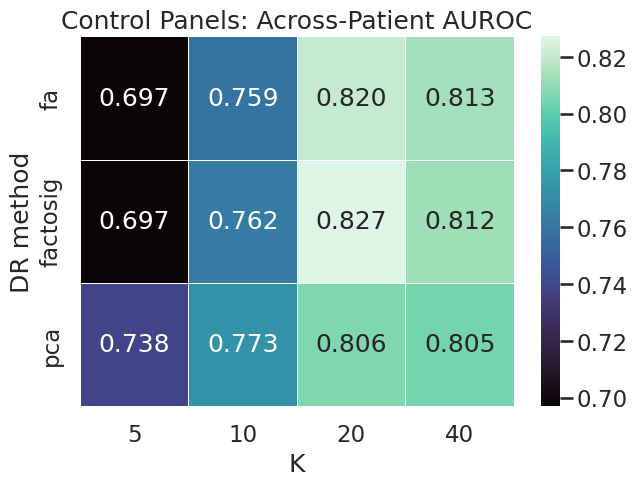

saved figures/stage0_bottom_up_postrun_20260518/control_across_patient_auprc_method_k_heatmap.png


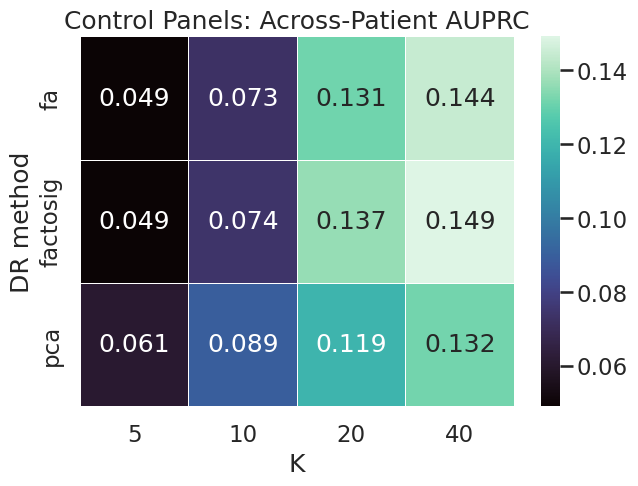

saved figures/stage0_bottom_up_postrun_20260518/control_knn_label_purity_macro_method_k_heatmap.png


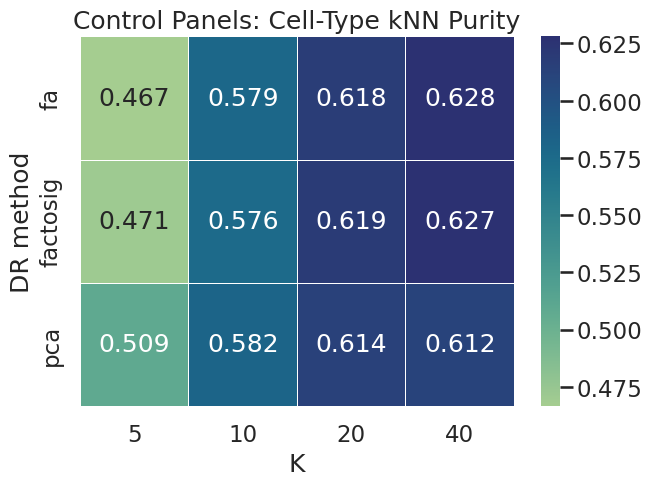

saved figures/stage0_bottom_up_postrun_20260518/control_pseudotime_knn_smoothness_method_k_heatmap.png


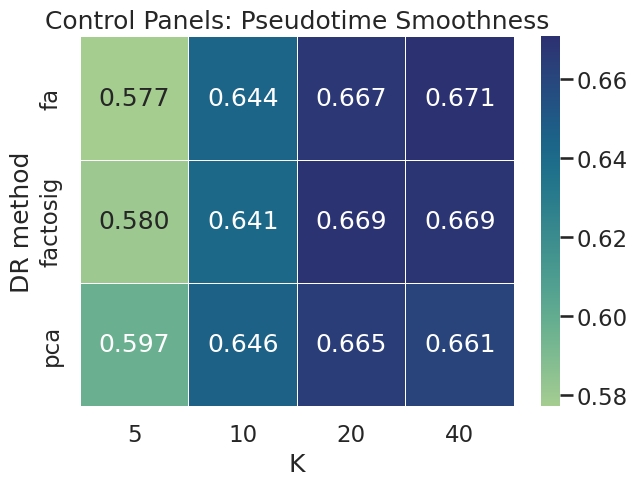

,panel_id,panel_type,method,K,n_genes,across_patient_auroc,across_patient_auprc,malignancy_rank_score,structure_rank_score,malignancy_first_score
5,hvg_size_matched_requested_1002__available_1002,hvg_size_matched_control,fa,20,1002,0.869883,0.176475,0.973251,0.957305,1.042258
1,hvg_top_requested_10000__available_1412,hvg_anchor_control,pca,20,1412,0.874609,0.195799,0.984053,0.998457,1.040379
0,hvg_top_requested_3000__available_1412,hvg_anchor_control,pca,20,1412,0.874609,0.195799,0.984053,0.998457,1.040379
2,hvg_size_matched_requested_1888__available_1412,hvg_size_matched_control,pca,20,1412,0.874609,0.195799,0.984053,0.998457,1.040379
3,hvg_size_matched_requested_3233__available_1412,hvg_size_matched_control,pca,20,1412,0.874609,0.195799,0.984053,0.998457,1.040379
8,hvg_top_requested_3000__available_1412,hvg_anchor_control,factosig,40,1412,0.858285,0.275227,0.983025,0.979938,1.039350
10,hvg_size_matched_requested_1888__available_1412,hvg_size_matched_control,factosig,40,1412,0.858285,0.275227,0.983025,0.979938,1.039350
9,hvg_top_requested_10000__available_1412,hvg_anchor_control,factosig,40,1412,0.858285,0.275227,0.983025,0.979938,1.039350
11,hvg_size_matched_requested_3233__available_1412,hvg_size_matched_control,factosig,40,1412,0.858285,0.275227,0.983025,0.979938,1.039350
17,hvg_size_matched_requested_1002__available_1002,hvg_size_matched_control,factosig,40,1002,0.851085,0.231510,0.970165,0.941872,1.039172


In [5]:
def savefig(fig, name: str):
    png = FIG_DIR / f"{name}.png"
    pdf = FIG_DIR / f"{name}.pdf"
    fig.savefig(png, dpi=180, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print(f"saved {png}")


def heatmap_method_k(data: pd.DataFrame, value: str, title: str, name: str, center=None, cmap="viridis"):
    if data.empty or value not in data.columns:
        print(f"skip {name}: missing data or {value}")
        return
    pivot = data.pivot_table(index="method", columns="K", values=value, aggfunc="mean")
    fig, ax = plt.subplots(figsize=(7, 4.8))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, center=center, linewidths=0.5, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("K")
    ax.set_ylabel("DR method")
    savefig(fig, name)
    plt.show()

control_types = ["full_control", "core_only", "hvg_anchor_control", "hvg_size_matched_control", "all_filtered_control"]
controls = ok[ok["panel_type"].isin(control_types)].copy()

for metric, title, cmap, center in [
    ("across_patient_auroc", "Control Panels: Across-Patient AUROC", "mako", None),
    ("across_patient_auprc", "Control Panels: Across-Patient AUPRC", "mako", None),
    ("knn_label_purity_macro", "Control Panels: Cell-Type kNN Purity", "crest", None),
    ("pseudotime_knn_smoothness", "Control Panels: Pseudotime Smoothness", "crest", None),
]:
    heatmap_method_k(controls, metric, title, f"control_{metric}_method_k_heatmap", center=center, cmap=cmap)

best_controls = controls.sort_values("malignancy_first_score", ascending=False).head(20)
display(best_controls[["panel_id", "panel_type", "method", "K", "n_genes", "across_patient_auroc", "across_patient_auprc", "malignancy_rank_score", "structure_rank_score", "malignancy_first_score"]])

## Malignancy Versus Structure Separation

These scatter plots reproduce the useful visual idea from the pruning triage notebook, but put malignancy-first decisions in the foreground.

saved figures/stage0_bottom_up_postrun_20260518/malignancy_vs_structure_scatter_all_panels.png


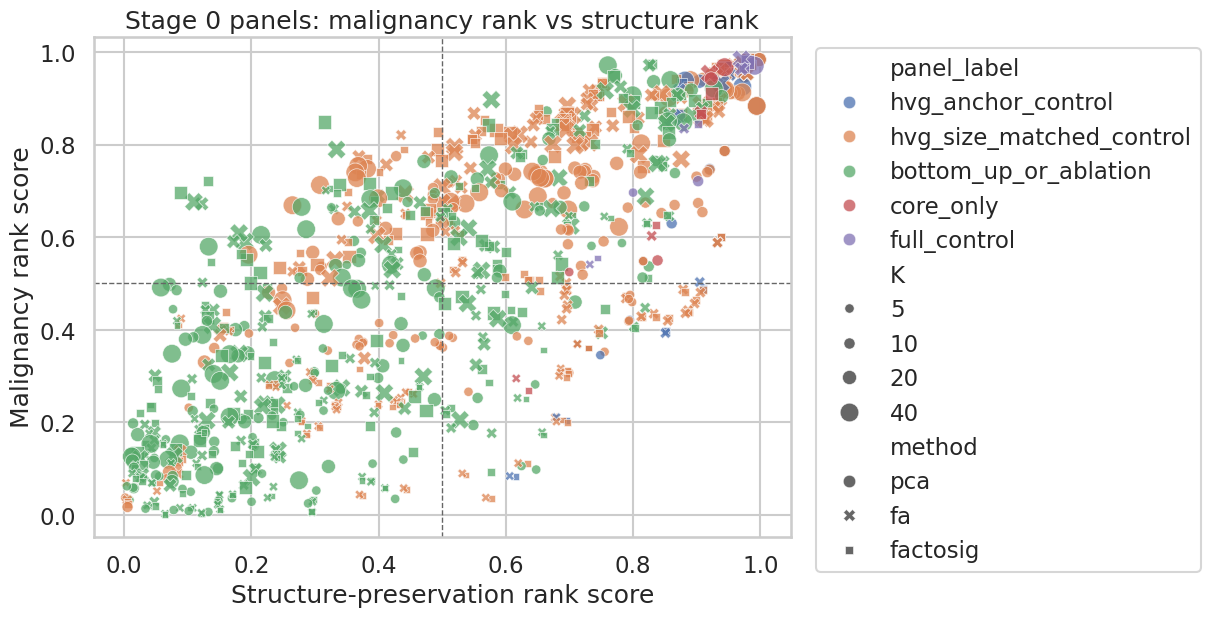

saved figures/stage0_bottom_up_postrun_20260518/top20_malignancy_first_scatter.png


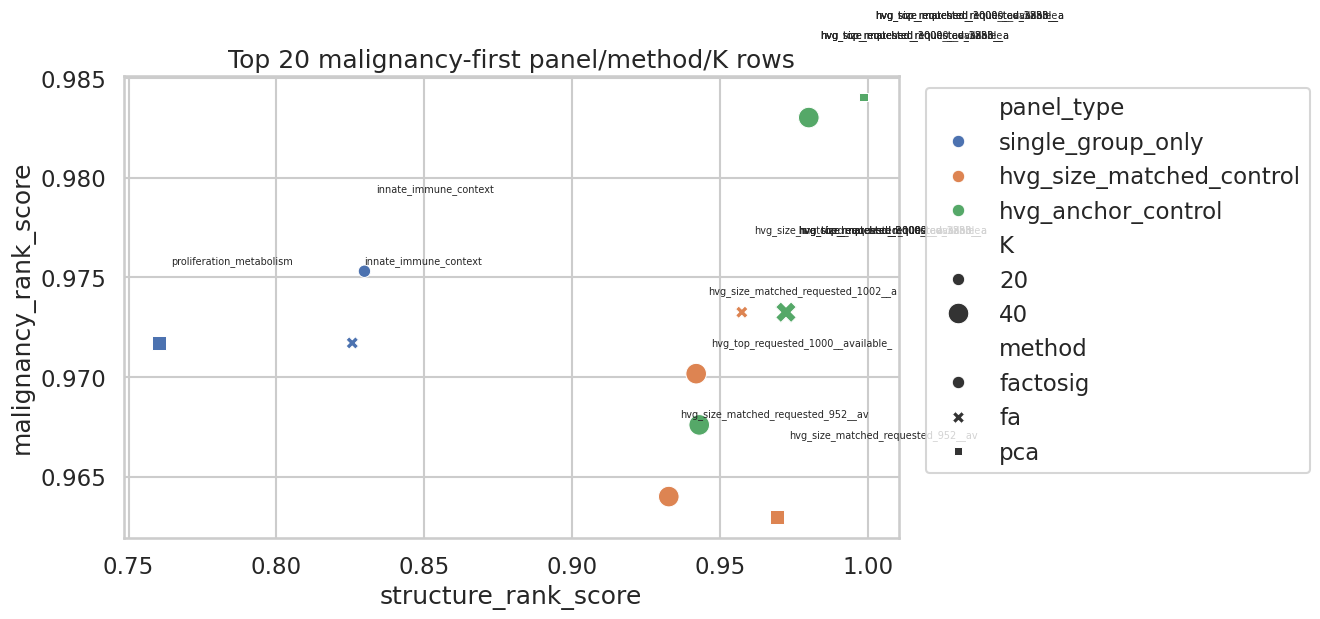

In [6]:
plot_df = ok.copy()
plot_df["panel_label"] = plot_df["panel_type"].where(plot_df["panel_type"].isin(control_types), "bottom_up_or_ablation")

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.scatterplot(
    data=plot_df,
    x="structure_rank_score",
    y="malignancy_rank_score",
    hue="panel_label",
    style="method",
    size="K",
    sizes=(45, 180),
    alpha=0.75,
    ax=ax,
)
ax.axvline(plot_df["structure_rank_score"].median(), color="0.4", ls="--", lw=1)
ax.axhline(plot_df["malignancy_rank_score"].median(), color="0.4", ls="--", lw=1)
ax.set_title("Stage 0 panels: malignancy rank vs structure rank")
ax.set_xlabel("Structure-preservation rank score")
ax.set_ylabel("Malignancy rank score")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
savefig(fig, "malignancy_vs_structure_scatter_all_panels")
plt.show()

# Highlight top malignancy-first rows.
top = plot_df.sort_values("malignancy_first_score", ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=top, x="structure_rank_score", y="malignancy_rank_score", hue="panel_type", style="method", size="K", sizes=(80, 220), ax=ax)
for _, row in top.iterrows():
    label = str(row["panel_id"]).replace("single_geneset__", "").replace("single_group__", "")[:34]
    ax.text(row["structure_rank_score"] + 0.004, row["malignancy_rank_score"] + 0.004, label, fontsize=7)
ax.set_title("Top 20 malignancy-first panel/method/K rows")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
savefig(fig, "top20_malignancy_first_scatter")
plt.show()

## Bottom-Up Value-Added Ranking

These tables select the best method/K per panel so individual genesets and biology groups can be compared without over-counting every K as a separate biological hit.

### Best Single Genesets

,panel_id,panel_type,method,K,n_genes,across_patient_auroc,across_patient_auprc,within_patient_mean_auroc,within_patient_mean_auprc,malignancy_rank_score,structure_rank_score,malignancy_first_score
3,single_geneset__reactome_cytokine_signaling_in_immune_system,single_geneset_only,pca,20,754,0.855349,0.138163,0.871287,0.353365,0.918210,0.891461,0.994888
5,single_geneset__hallmark_inflammatory_response,single_geneset_only,fa,40,200,0.813712,0.198466,0.855687,0.344521,0.897119,0.577160,0.990933
6,single_geneset__hallmark_allograft_rejection,single_geneset_only,pca,10,190,0.831292,0.134652,0.833554,0.302041,0.871914,0.664095,0.966037
8,single_geneset__hallmark_glycolysis,single_geneset_only,factosig,40,197,0.799027,0.170820,0.830379,0.344920,0.849280,0.315329,0.943186
10,single_geneset__reactome_mhc_class_i_antigen_presentation,single_geneset_only,fa,20,369,0.815401,0.098695,0.837649,0.314677,0.782407,0.617284,0.870994
11,single_geneset__hallmark_p53_pathway,single_geneset_only,pca,20,195,0.781376,0.139119,0.840375,0.314278,0.763889,0.471193,0.857857
12,single_geneset__hallmark_oxidative_phosphorylation,single_geneset_only,factosig,20,200,0.780667,0.114280,0.795535,0.276680,0.721193,0.132202,0.815007
13,single_geneset__hallmark_complement,single_geneset_only,fa,20,199,0.785772,0.102711,0.821125,0.335282,0.718107,0.576132,0.811952
14,single_geneset__kegg_jak_stat_signaling_pathway,single_geneset_only,factosig,40,140,0.781595,0.106635,0.835325,0.320233,0.714506,0.337963,0.810176
15,single_geneset__hallmark_mtorc1_signaling,single_geneset_only,factosig,40,197,0.800081,0.089612,0.881484,0.403303,0.715535,0.385288,0.809442


### Best Single Biology Groups

,panel_id,panel_type,method,K,n_genes,across_patient_auroc,across_patient_auprc,within_patient_mean_auroc,within_patient_mean_auprc,malignancy_rank_score,structure_rank_score,malignancy_first_score
0,single_group__innate_immune_context,single_group_only,factosig,20,443,0.859469,0.197072,0.868176,0.382170,0.975309,0.829733,1.061606
1,single_group__proliferation_metabolism,single_group_only,pca,40,1002,0.853306,0.228661,0.890520,0.431086,0.971708,0.760288,1.040715
2,single_group__stress_arrest,single_group_only,pca,40,785,0.843669,0.171169,0.890809,0.444651,0.939815,0.858539,1.015534
4,single_group__cytokine_jak_stat,single_group_only,pca,40,952,0.849511,0.141641,0.894759,0.402172,0.921296,0.926955,0.991850
7,single_group__inflammatory_interferon,single_group_only,factosig,40,733,0.816116,0.148279,0.904856,0.474964,0.869342,0.828704,0.946669
9,single_group__antigen_presentation,single_group_only,fa,20,514,0.827688,0.112387,0.845899,0.330574,0.830761,0.716049,0.914863
16,single_group__tgf_plasticity,single_group_only,factosig,10,246,0.794639,0.093936,0.838548,0.319230,0.711420,0.525720,0.803811


saved figures/stage0_bottom_up_postrun_20260518/top_bottom_up_panels_barplot.png


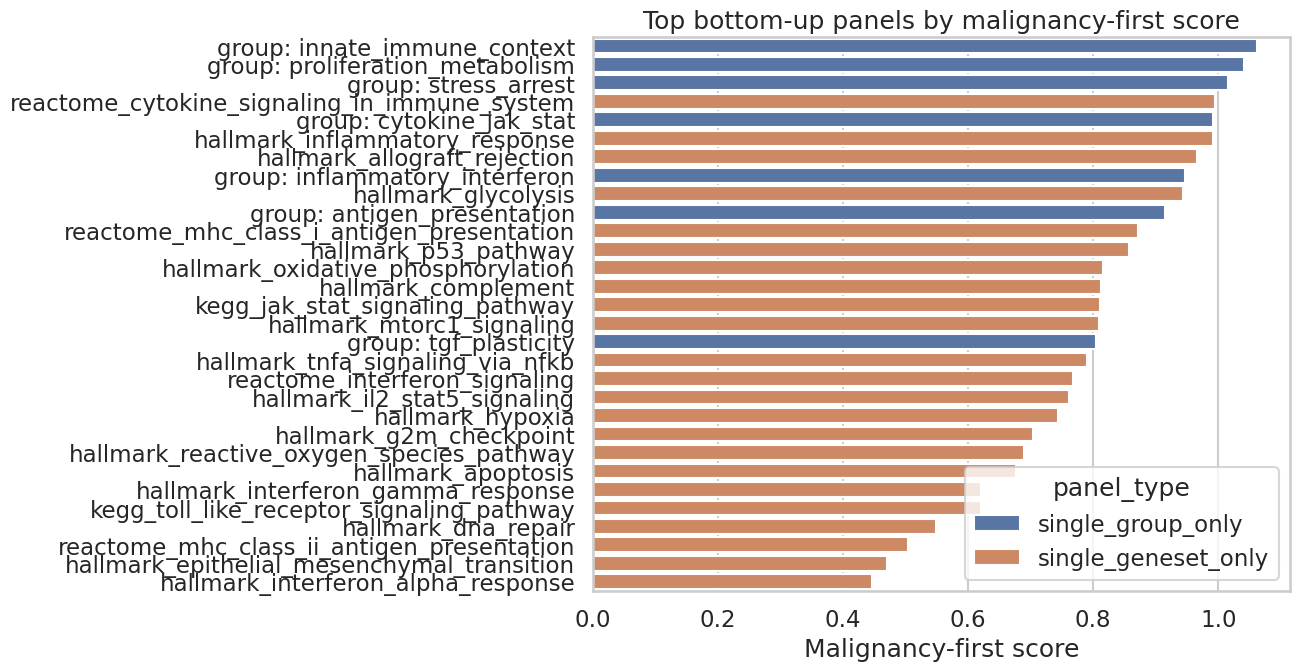

In [7]:
def best_per_panel(data: pd.DataFrame, score_col="malignancy_first_score") -> pd.DataFrame:
    return (
        data.sort_values([score_col, "across_patient_auroc", "across_patient_auprc"], ascending=False)
        .groupby("panel_id", as_index=False, sort=False)
        .head(1)
        .reset_index(drop=True)
    )

bottom_types = ["single_geneset_only", "single_group_only"]
bottom = ok[ok["panel_type"].isin(bottom_types)].copy()
best_bottom = best_per_panel(bottom)

cols = [
    "panel_id", "panel_type", "method", "K", "n_genes",
    "across_patient_auroc", "across_patient_auprc",
    "within_patient_mean_auroc", "within_patient_mean_auprc",
    "malignancy_rank_score", "structure_rank_score", "malignancy_first_score",
]

display(Markdown("### Best Single Genesets"))
display(best_bottom[best_bottom["panel_type"].eq("single_geneset_only")][cols].head(25))

display(Markdown("### Best Single Biology Groups"))
display(best_bottom[best_bottom["panel_type"].eq("single_group_only")][cols].head(25))

fig, ax = plt.subplots(figsize=(9, max(5, 0.24 * min(30, len(best_bottom)))))
plot_top = best_bottom.head(30).copy()
plot_top["short_panel"] = plot_top["panel_id"].str.replace("single_geneset__", "", regex=False).str.replace("single_group__", "group: ", regex=False).str[:55]
sns.barplot(data=plot_top, y="short_panel", x="malignancy_first_score", hue="panel_type", dodge=False, ax=ax)
ax.set_title("Top bottom-up panels by malignancy-first score")
ax.set_xlabel("Malignancy-first score")
ax.set_ylabel("")
savefig(fig, "top_bottom_up_panels_barplot")
plt.show()

## Knowledge Panels Versus HVG Controls

For each knowledge-driven row, compare against the nearest available HVG control at the same method and K by absolute difference in gene count. This is a pragmatic post-hoc size-matched check because some requested HVG sizes collapse to the same available overlap.

knowledge-vs-HVG matched rows: (504, 23)


,panel_id,panel_type,method,K,n_genes,hvg_panel_id,hvg_n_genes,hvg_size_absdiff,across_patient_auroc,hvg_across_patient_auroc,delta_vs_nearest_hvg_across_patient_auroc,across_patient_auprc,hvg_across_patient_auprc,delta_vs_nearest_hvg_across_patient_auprc,malignancy_rank_score,hvg_malignancy_rank_score,delta_vs_nearest_hvg_malignancy_rank_score,structure_rank_score,hvg_structure_rank_score,delta_vs_nearest_hvg_structure_rank_score,malignancy_first_score,hvg_malignancy_first_score,delta_vs_nearest_hvg_malignancy_first_score
165,single_geneset__reactome_mhc_class_i_antigen_presentation,single_geneset_only,factosig,5,369,hvg_size_matched_requested_369__available_369,369,0.0,0.798568,0.648496,0.150072,0.089136,0.034994,0.054142,0.705761,0.085905,0.619856,0.323560,0.537551,-0.213992,0.794348,0.174492,0.619856
169,single_geneset__reactome_mhc_class_i_antigen_presentation,single_geneset_only,fa,5,369,hvg_size_matched_requested_369__available_369,369,0.0,0.798044,0.649426,0.148618,0.088535,0.035137,0.053398,0.701132,0.089506,0.611626,0.316872,0.531379,-0.214506,0.789718,0.178093,0.611626
78,single_group__cytokine_jak_stat,single_group_only,factosig,5,952,hvg_size_matched_requested_952__available_952,952,0.0,0.789329,0.699888,0.089441,0.078590,0.046429,0.032160,0.641461,0.204733,0.436728,0.764918,0.689300,0.075617,0.712015,0.275286,0.436728
79,single_group__cytokine_jak_stat,single_group_only,fa,5,952,hvg_size_matched_requested_952__available_952,952,0.0,0.789790,0.700423,0.089367,0.079167,0.046590,0.032576,0.645062,0.210391,0.434671,0.754630,0.676955,0.077675,0.715615,0.280945,0.434671
157,single_group__innate_immune_context,single_group_only,fa,5,443,hvg_size_matched_requested_443__available_443,443,0.0,0.749517,0.612060,0.137457,0.060042,0.030595,0.029446,0.407922,0.037037,0.370885,0.656379,0.568416,0.087963,0.494219,0.123335,0.370885
47,single_group__innate_immune_context,single_group_only,fa,10,443,hvg_size_matched_requested_443__available_443,443,0.0,0.818221,0.751964,0.066256,0.099388,0.063716,0.035672,0.791152,0.434671,0.356481,0.790638,0.832305,-0.041667,0.877450,0.520968,0.356481
48,single_group__innate_immune_context,single_group_only,factosig,10,443,hvg_size_matched_requested_443__available_443,443,0.0,0.817294,0.750793,0.066501,0.097208,0.062806,0.034402,0.782922,0.426955,0.355967,0.795267,0.836420,-0.041152,0.869219,0.513252,0.355967
89,single_geneset__reactome_cytokine_signaling_in_immune_system,single_geneset_only,factosig,5,754,hvg_size_matched_requested_754__available_754,754,0.0,0.788252,0.721273,0.066979,0.081758,0.052978,0.028781,0.648148,0.305041,0.343107,0.704733,0.698560,0.006173,0.724826,0.381719,0.343107
92,single_geneset__reactome_cytokine_signaling_in_immune_system,single_geneset_only,fa,5,754,hvg_size_matched_requested_754__available_754,754,0.0,0.787824,0.722132,0.065692,0.081702,0.053274,0.028428,0.646605,0.308128,0.338477,0.699074,0.686214,0.012860,0.723283,0.384806,0.338477
54,single_geneset__hallmark_allograft_rejection,single_geneset_only,factosig,10,190,hvg_size_matched_requested_190__available_190,190,0.0,0.836845,0.765364,0.071481,0.112695,0.070349,0.042346,0.850309,0.513374,0.336934,0.676955,0.598765,0.078189,0.944432,0.607498,0.336934


saved figures/stage0_bottom_up_postrun_20260518/knowledge_vs_nearest_hvg_delta_scatter.png


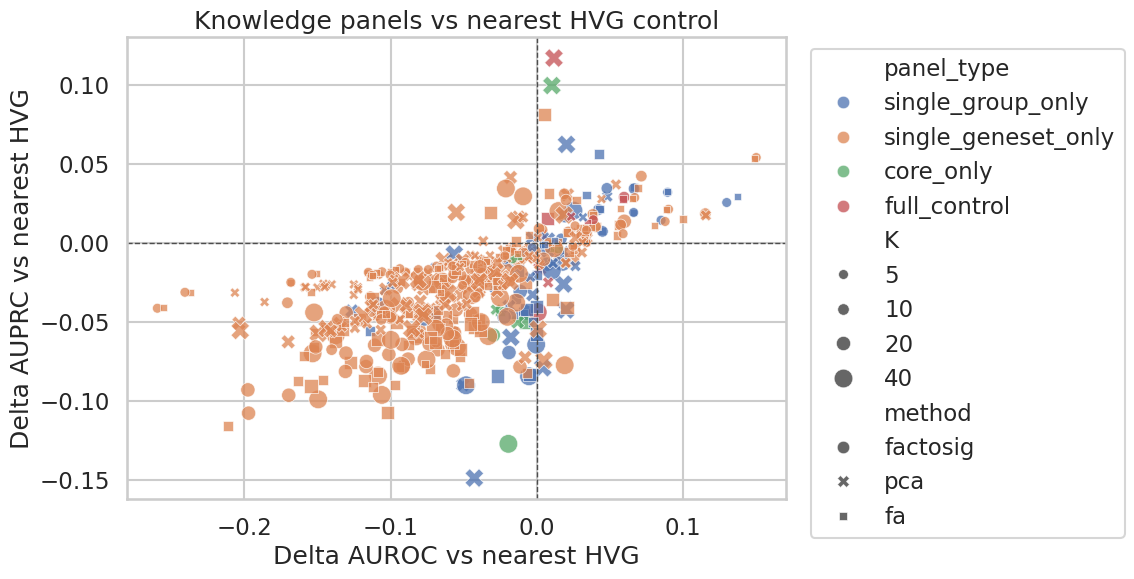

saved figures/stage0_bottom_up_postrun_20260518/knowledge_vs_nearest_hvg_comparison.csv


In [8]:
knowledge = ok[ok["panel_family"].eq("knowledge_old_geneset")].copy()
hvg_controls = ok[ok["panel_type"].isin(["hvg_anchor_control", "hvg_size_matched_control"])].copy()

comparison_rows = []
for _, row in knowledge.iterrows():
    candidates = hvg_controls[(hvg_controls["method"].eq(row["method"])) & (hvg_controls["K"].eq(row["K"]))].copy()
    if candidates.empty:
        continue
    candidates["size_absdiff"] = (pd.to_numeric(candidates["n_genes"], errors="coerce") - float(row["n_genes"])).abs()
    ctrl = candidates.sort_values(["size_absdiff", "n_genes"]).iloc[0]
    out = {
        "panel_id": row["panel_id"],
        "panel_type": row["panel_type"],
        "method": row["method"],
        "K": row["K"],
        "n_genes": row["n_genes"],
        "hvg_panel_id": ctrl["panel_id"],
        "hvg_n_genes": ctrl["n_genes"],
        "hvg_size_absdiff": ctrl["size_absdiff"],
    }
    for metric in ["across_patient_auroc", "across_patient_auprc", "malignancy_rank_score", "structure_rank_score", "malignancy_first_score"]:
        out[metric] = row.get(metric, np.nan)
        out[f"hvg_{metric}"] = ctrl.get(metric, np.nan)
        out[f"delta_vs_nearest_hvg_{metric}"] = row.get(metric, np.nan) - ctrl.get(metric, np.nan)
    comparison_rows.append(out)

hvg_cmp = pd.DataFrame(comparison_rows)
print("knowledge-vs-HVG matched rows:", hvg_cmp.shape)
if not hvg_cmp.empty:
    display(hvg_cmp.sort_values("delta_vs_nearest_hvg_malignancy_first_score", ascending=False).head(25))

    fig, ax = plt.subplots(figsize=(8.5, 6))
    sns.scatterplot(
        data=hvg_cmp,
        x="delta_vs_nearest_hvg_across_patient_auroc",
        y="delta_vs_nearest_hvg_across_patient_auprc",
        hue="panel_type",
        style="method",
        size="K",
        sizes=(50, 180),
        alpha=0.75,
        ax=ax,
    )
    ax.axvline(0, color="0.3", ls="--", lw=1)
    ax.axhline(0, color="0.3", ls="--", lw=1)
    ax.set_title("Knowledge panels vs nearest HVG control")
    ax.set_xlabel("Delta AUROC vs nearest HVG")
    ax.set_ylabel("Delta AUPRC vs nearest HVG")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    savefig(fig, "knowledge_vs_nearest_hvg_delta_scatter")
    plt.show()

    hvg_cmp.to_csv(FIG_DIR / "knowledge_vs_nearest_hvg_comparison.csv", index=False)
    print("saved", FIG_DIR / "knowledge_vs_nearest_hvg_comparison.csv")

## K And DR Consistency Diagnostics

Non-monotonic behavior across K can be real, but this section flags panels/methods where performance changes sharply across dimensions.

,panel_id,panel_type,method,metric,n_K,min_value,max_value,range,n_negative_steps,largest_drop,best_K,best_value
137,single_geneset__hallmark_dna_repair,single_geneset_only,pca,across_patient_auroc,4,0.724467,0.748712,0.024245,3,-0.010503,5,0.748712
128,single_geneset__hallmark_allograft_rejection,single_geneset_only,pca,across_patient_auroc,4,0.661251,0.831292,0.170041,2,-0.020861,10,0.831292
181,single_geneset__hallmark_p53_pathway,single_geneset_only,factosig,across_patient_auroc,4,0.636031,0.782840,0.146809,2,-0.026104,10,0.782840
650,single_geneset__hallmark_hypoxia,single_geneset_only,pca,knn_label_purity_macro,4,0.351876,0.477562,0.125686,2,-0.023568,10,0.477562
894,single_geneset__hallmark_glycolysis,single_geneset_only,fa,pseudotime_knn_smoothness,4,0.425487,0.548562,0.123075,2,-0.012101,10,0.548562
802,hvg_size_matched_requested_246__available_246,hvg_size_matched_control,factosig,pseudotime_knn_smoothness,4,0.560486,0.680906,0.120419,2,-0.016681,10,0.680906
653,single_geneset__hallmark_il2_stat5_signaling,single_geneset_only,pca,knn_label_purity_macro,4,0.465751,0.579198,0.113447,2,-0.031397,10,0.579198
99,hvg_size_matched_requested_86__available_86,hvg_size_matched_control,fa,across_patient_auroc,4,0.696692,0.804236,0.107543,2,-0.014116,10,0.804236
823,hvg_size_matched_requested_49__available_49,hvg_size_matched_control,factosig,pseudotime_knn_smoothness,4,0.417905,0.521772,0.103867,2,-0.030920,10,0.521772
931,single_geneset__hallmark_reactive_oxygen_species_pathway,single_geneset_only,factosig,pseudotime_knn_smoothness,4,0.362594,0.463297,0.100703,2,-0.025367,10,0.463297


saved figures/stage0_bottom_up_postrun_20260518/k_behavior_diagnostics.csv
saved figures/stage0_bottom_up_postrun_20260518/top_panel_auroc_vs_k_facets.png


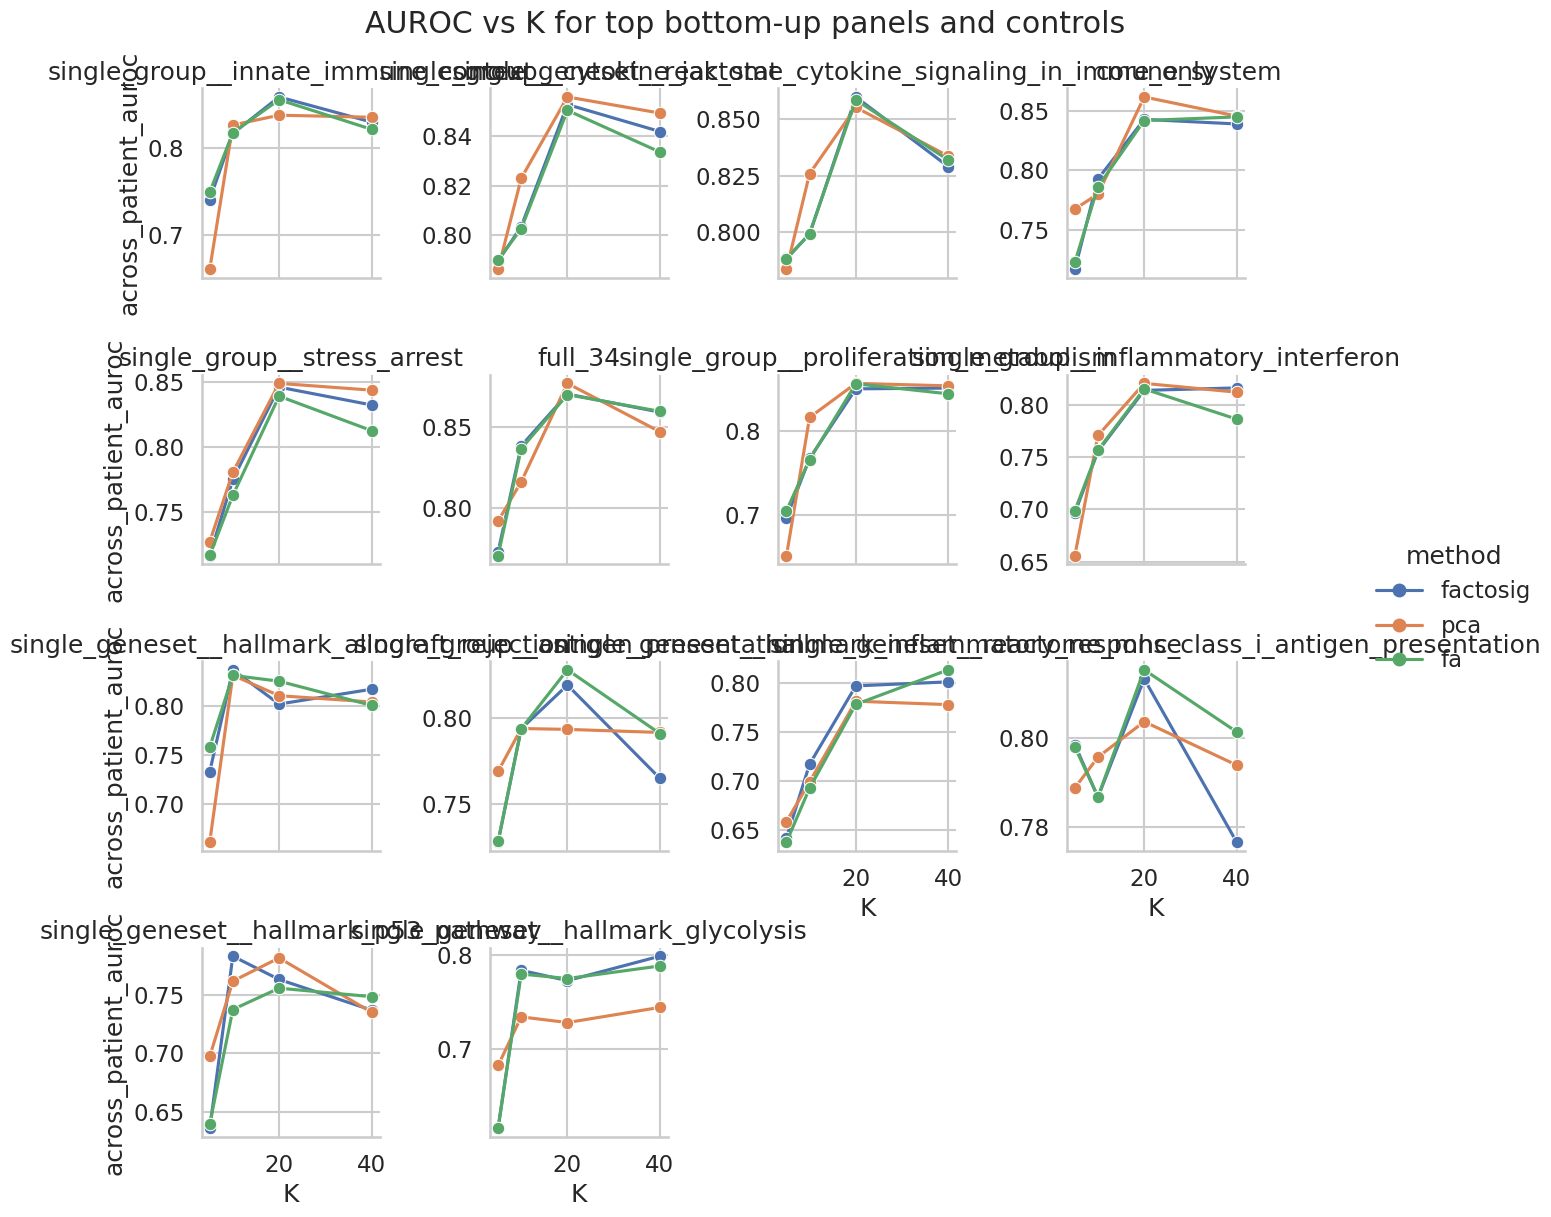

In [9]:
def k_behavior_table(data: pd.DataFrame, metric: str) -> pd.DataFrame:
    rows = []
    group_cols = ["panel_id", "panel_type", "method"]
    for keys, sub in data.dropna(subset=[metric]).sort_values("K").groupby(group_cols, dropna=False):
        vals = sub[["K", metric]].dropna().sort_values("K")
        if len(vals) < 2:
            continue
        diffs = vals[metric].diff().dropna()
        rows.append({
            "panel_id": keys[0],
            "panel_type": keys[1],
            "method": keys[2],
            "metric": metric,
            "n_K": len(vals),
            "min_value": vals[metric].min(),
            "max_value": vals[metric].max(),
            "range": vals[metric].max() - vals[metric].min(),
            "n_negative_steps": int((diffs < -1e-9).sum()),
            "largest_drop": float(diffs.min()) if not diffs.empty else np.nan,
            "best_K": vals.loc[vals[metric].idxmax(), "K"],
            "best_value": vals[metric].max(),
        })
    return pd.DataFrame(rows)

k_diag = pd.concat([k_behavior_table(ok, m) for m in ["across_patient_auroc", "across_patient_auprc", "knn_label_purity_macro", "pseudotime_knn_smoothness"]], ignore_index=True)
if not k_diag.empty:
    display(k_diag.sort_values(["n_negative_steps", "range"], ascending=False).head(30))
    k_diag.to_csv(FIG_DIR / "k_behavior_diagnostics.csv", index=False)
    print("saved", FIG_DIR / "k_behavior_diagnostics.csv")

focus_metric = "across_patient_auroc"
focus = best_bottom.head(12)["panel_id"].tolist() + ["full_34", "core_only"]
focus_df = ok[ok["panel_id"].isin(focus)]
if not focus_df.empty:
    g = sns.relplot(
        data=focus_df,
        x="K",
        y=focus_metric,
        hue="method",
        col="panel_id",
        col_wrap=4,
        kind="line",
        marker="o",
        facet_kws={"sharey": False},
        height=3.0,
    )
    g.fig.suptitle("AUROC vs K for top bottom-up panels and controls", y=1.02)
    g.set_titles("{col_name}")
    savefig(g.fig, "top_panel_auroc_vs_k_facets")
    plt.show()

## Panel Size, Parsimony, And Performance

saved figures/stage0_bottom_up_postrun_20260518/panel_size_vs_malignancy_metrics.png


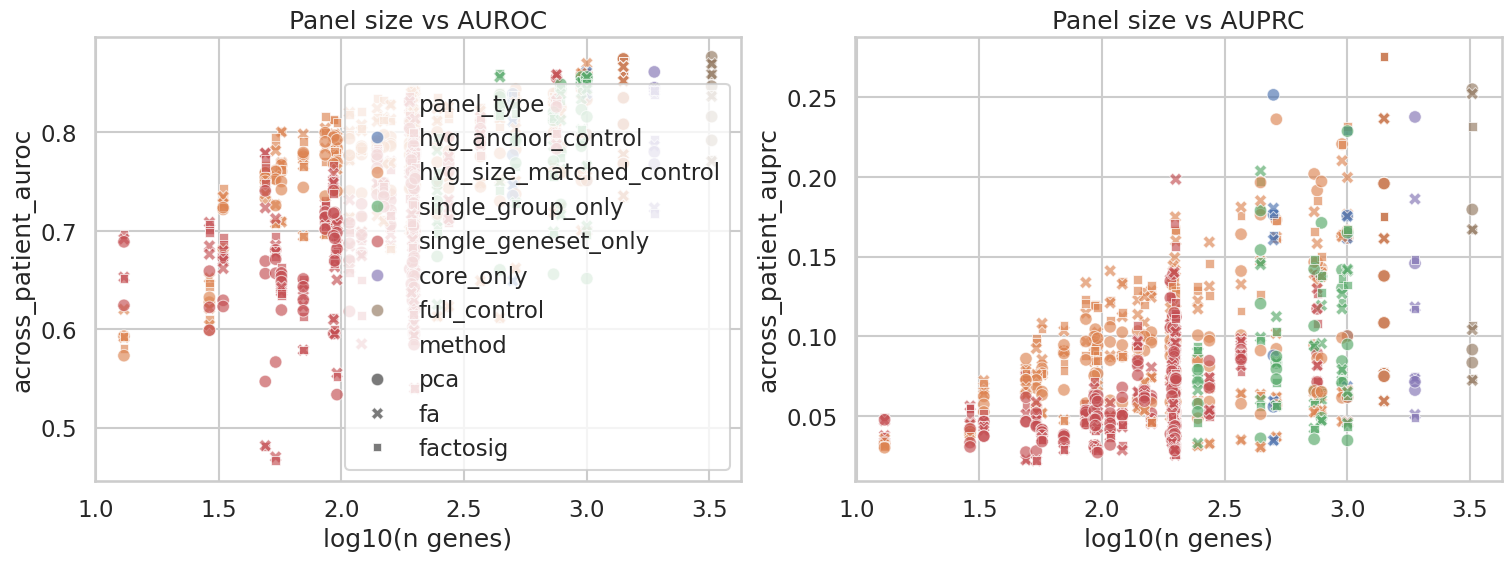

,n_rows,n_panels,median_n_genes,best_auroc,best_auprc,best_malignancy_first
panel_type,,,,,,
single_group_only,84,7,733.0,0.859469,0.228661,1.061606
hvg_size_matched_control,420,36,195.0,0.874609,0.275227,1.042258
hvg_anchor_control,48,4,1206.0,0.874609,0.275227,1.040379
core_only,12,1,1888.0,0.861406,0.237566,1.009195
single_geneset_only,396,34,193.0,0.859963,0.198466,0.994888
full_control,12,1,3233.0,0.876656,0.254960,0.984568


In [10]:
size_df = ok.copy()
size_df["log10_n_genes"] = np.log10(pd.to_numeric(size_df["n_genes"], errors="coerce").clip(lower=1))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
sns.scatterplot(data=size_df, x="log10_n_genes", y="across_patient_auroc", hue="panel_type", style="method", alpha=0.65, ax=axes[0])
axes[0].set_title("Panel size vs AUROC")
axes[0].set_xlabel("log10(n genes)")
sns.scatterplot(data=size_df, x="log10_n_genes", y="across_patient_auprc", hue="panel_type", style="method", alpha=0.65, ax=axes[1], legend=False)
axes[1].set_title("Panel size vs AUPRC")
axes[1].set_xlabel("log10(n genes)")
savefig(fig, "panel_size_vs_malignancy_metrics")
plt.show()

size_summary = size_df.groupby("panel_type").agg(
    n_rows=("panel_id", "size"),
    n_panels=("panel_id", "nunique"),
    median_n_genes=("n_genes", "median"),
    best_auroc=("across_patient_auroc", "max"),
    best_auprc=("across_patient_auprc", "max"),
    best_malignancy_first=("malignancy_first_score", "max"),
).sort_values("best_malignancy_first", ascending=False)
display(size_summary)

## Optional Stage 2 Hyperparameter Diagnostics

If `run_plan1c_supervised_latent_benchmark.py` has been run under this Stage 0 output directory, this section loads the consolidated supervised CV tables and visualizes penalty/alpha behavior. It is safe to leave this section unexecuted until those outputs exist.

In [11]:
stage2_roots = sorted(OUT_DIR.glob("plan1c_supervised_from_scores_k*/")) + sorted(OUT_DIR.glob("*/plan1c_supervised_from_scores_k*/"))
print("stage2 candidate roots:")
for root in stage2_roots:
    print(" -", root)

if not stage2_roots:
    display(Markdown("No Stage 2 Plan 1.C outputs found under the Stage 0 directory yet. Run `run_plan1c_supervised_latent_benchmark.py --feature-manifest-csv ...` to enable this section."))
else:
    stage2_root = stage2_roots[-1]
    pooled_path = stage2_root / "pooled_grid_metrics.csv"
    per_patient_path = stage2_root / "per_patient_grid_metrics.csv"
    best_path = stage2_root / "pooled_best_by_objective.csv"
    print("using", stage2_root)

    pooled = pd.read_csv(pooled_path) if pooled_path.exists() else pd.DataFrame()
    per_patient = pd.read_csv(per_patient_path) if per_patient_path.exists() else pd.DataFrame()
    pooled_best = pd.read_csv(best_path) if best_path.exists() else pd.DataFrame()

    if not pooled.empty:
        pooled["log10_alpha"] = np.log10(pd.to_numeric(pooled["alpha"], errors="coerce"))
        display(pooled.sort_values("auc_mean", ascending=False).head(20))
        top_methods = pooled.groupby("method")["auc_mean"].max().sort_values(ascending=False).head(12).index
        plot_pooled = pooled[pooled["method"].isin(top_methods)].copy()
        g = sns.relplot(
            data=plot_pooled,
            x="log10_alpha",
            y="auc_mean",
            hue="penalty",
            col="method",
            col_wrap=4,
            kind="line",
            marker="o",
            height=3.0,
            facet_kws={"sharey": False},
        )
        g.fig.suptitle("Stage 2 pooled CV AUROC regularization paths", y=1.02)
        savefig(g.fig, "stage2_pooled_auc_regularization_paths")
        plt.show()

    if not pooled_best.empty:
        display(Markdown("### Pooled Best By Objective"))
        display(pooled_best.sort_values("auc_mean", ascending=False).head(30))

    if not per_patient.empty:
        display(Markdown("### Per-Patient Stage 2 Summary"))
        per_patient_summary = per_patient.groupby(["method", "penalty"]).agg(
            mean_auc=("auc_mean", "mean"),
            median_auc=("auc_mean", "median"),
            mean_ap=("ap_mean", "mean"),
            n_rows=("patient", "size") if "patient" in per_patient.columns else ("method", "size"),
        ).reset_index().sort_values("mean_auc", ascending=False)
        display(per_patient_summary.head(30))

stage2 candidate roots:


No Stage 2 Plan 1.C outputs found under the Stage 0 directory yet. Run `run_plan1c_supervised_latent_benchmark.py --feature-manifest-csv ...` to enable this section.

## Export Compact Summary Tables

In [12]:
exports = {}
exports["best_bottom_up_panels"] = best_bottom
if "hvg_cmp" in globals() and not hvg_cmp.empty:
    exports["knowledge_vs_nearest_hvg"] = hvg_cmp
if "k_diag" in globals() and not k_diag.empty:
    exports["k_behavior_diagnostics"] = k_diag
exports["panel_type_summary"] = size_summary.reset_index() if "size_summary" in globals() else pd.DataFrame()

for name, table in exports.items():
    if table is None or table.empty:
        continue
    out_path = FIG_DIR / f"{name}.csv"
    table.to_csv(out_path, index=False)
    print("saved", out_path)

display(Markdown(f"Figures and summary tables are under `{FIG_DIR.resolve()}`."))

saved figures/stage0_bottom_up_postrun_20260518/best_bottom_up_panels.csv
saved figures/stage0_bottom_up_postrun_20260518/knowledge_vs_nearest_hvg.csv
saved figures/stage0_bottom_up_postrun_20260518/k_behavior_diagnostics.csv
saved figures/stage0_bottom_up_postrun_20260518/panel_type_summary.csv


Figures and summary tables are under `/home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/figures/stage0_bottom_up_postrun_20260518`.